In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Load datasets
sk_cov = pd.read_csv('sk_covariance_classification.csv')
gev_summary = pd.read_csv('summary_bulk_and_gev.csv')

# Display the datasets
print("SK Covariance Classification Data:")
print(sk_cov)
print("\n" + "="*80 + "\n")
print("GEV Summary Data:")
print(gev_summary)


SK Covariance Classification Data:
 Function_ID Function_Name RH_Status CS_N CG_N \
0 F1 Riemann ζ True -2.145868 -48.166024 
1 F2 L(χ₄) real mod 5 True -0.911860 -141.092943 
2 F3 L(χ) complex mod 5 True -1.392495 -73.487153 
3 F4 Random multiplicative NaN -0.698308 -28.874906 
4 F5 Davenport-Heilbronn False -1.015625 -58.848451 
5 F6 Liouville L(s,λ) NaN -1.201193 -1.543072 
6 F7 Möbius L(s,μ) NaN -0.480808 251.765687 
7 F8 Fully random NaN -0.284477 -119.689792 

 Sum_Offdiag_N1 Sum_Offdiag_N2 N_Negative_N1 N_Negative_N2 \
0 -1.382172 -2.047909 22 20 
1 -0.373290 -0.899975 16 24 
2 -0.798141 -1.384673 18 28 
3 -0.443553 -0.571629 16 16 
4 -0.615537 -0.977771 20 20 
5 -1.089483 -1.106294 20 16 
6 -0.085233 0.129354 14 10 
7 -0.025751 -0.056572 14 18 

 Sum_Negative_N1 Sum_Negative_N2 Distance_to_RH_centroid 
0 -1.408797 -2.145868 0.770854 
1 -0.375498 -0.911860 0.782948 
2 -0.800255 -1.392495 0.167725 
3 -0.478986 -0.698308 0.980324 
4 -0.622760 -1.015625 0.548983 
5 -1.113870 -1.201

In [2]:

# Step 1: Data Consolidation
# Create a unified dataset by matching functions

# First, let's create a common Function ID for merging
# Extract Function ID from the GEV summary Function column
gev_summary['Function_ID'] = gev_summary['Function'].str.split(':').str[0]

# Now merge on Function_ID
merged_data = pd.merge(sk_cov, gev_summary, on='Function_ID', how='inner')

print(f"Merged dataset shape: {merged_data.shape}")
print("\nMerged dataset columns:")
print(merged_data.columns.tolist())
print("\nMerged dataset preview:")
print(merged_data[['Function_ID', 'Function_Name', 'CS_N', 'CG_N', 'xi_shape', 'xi_SE']])


Merged dataset shape: (8, 21)

Merged dataset columns:
['Function_ID', 'Function_Name', 'RH_Status', 'CS_N', 'CG_N', 'Sum_Offdiag_N1', 'Sum_Offdiag_N2', 'N_Negative_N1', 'N_Negative_N2', 'Sum_Negative_N1', 'Sum_Negative_N2', 'Distance_to_RH_centroid', 'Function', 'Mean', 'Variance', 'Skewness', 'Excess_Kurtosis', 'xi_shape', 'xi_SE', 'xi_CI_lower', 'xi_CI_upper']

Merged dataset preview:
 Function_ID Function_Name CS_N CG_N xi_shape xi_SE
0 F1 Riemann ζ -2.145868 -48.166024 -0.372965 0.024276
1 F2 L(χ₄) real mod 5 -0.911860 -141.092943 -0.319997 0.028342
2 F3 L(χ) complex mod 5 -1.392495 -73.487153 -0.267277 0.034377
3 F4 Random multiplicative -0.698308 -28.874906 -0.223911 0.032517
4 F5 Davenport-Heilbronn -1.015625 -58.848451 -0.314893 0.030726
5 F6 Liouville L(s,λ) -1.201193 -1.543072 -0.184682 0.034735
6 F7 Möbius L(s,μ) -0.480808 251.765687 -0.243025 0.027951
7 F8 Fully random -0.284477 -119.689792 -1.369802 0.000000


In [3]:

# Step 2: Feature Engineering
# We need to extract the diagonal terms (variances C_kk) from the covariance matrix at N=10^6
# These are not directly available in the sk_covariance_classification.csv file

# Let's check what we have available
print("Available features in sk_covariance_classification.csv:")
print(sk_cov.columns.tolist())
print("\nData description:")
print(sk_cov.describe())


Available features in sk_covariance_classification.csv:
['Function_ID', 'Function_Name', 'RH_Status', 'CS_N', 'CG_N', 'Sum_Offdiag_N1', 'Sum_Offdiag_N2', 'N_Negative_N1', 'N_Negative_N2', 'Sum_Negative_N1', 'Sum_Negative_N2', 'Distance_to_RH_centroid']

Data description:
 CS_N CG_N Sum_Offdiag_N1 Sum_Offdiag_N2 N_Negative_N1 \
count 8.000000 8.000000 8.000000 8.000000 8.000000 
mean -1.016329 -27.492082 -0.601645 -0.864434 17.500000 
std 0.583827 121.650505 0.472302 0.704055 2.976095 
min -2.145868 -141.092943 -1.382172 -2.047909 14.000000 
25% -1.249019 -85.037813 -0.870977 -1.175889 15.500000 
50% -0.963742 -53.507238 -0.529545 -0.938873 17.000000 
75% -0.643933 -22.041948 -0.301275 -0.442865 20.000000 
max -0.284477 251.765687 -0.025751 0.129354 22.000000 

 N_Negative_N2 Sum_Negative_N1 Sum_Negative_N2 \
count 8.000000 8.000000 8.000000 
mean 19.000000 -0.659494 -1.016329 
std 5.451081 0.426637 0.583827 
min 10.000000 -1.408797 -2.145868 
25% 16.000000 -0.878659 -1.249019 
50% 19.0

In [4]:

# The diagonal terms (variances C_kk) are not in the provided file.
# According to the objective, we should include them as potential predictor variables.
# However, since they're not available in the artifact, we need to work with what we have.

# Let's check if we can infer or compute them from available data
# The covariance file has Sum_Offdiag at both N values, but not the diagonal terms

# For now, let's proceed with the available features:
# - CS_N: Sum of negative off-diagonal terms at N=10^6 (primary metric)
# - CG_N: Percentage growth from N=10^5 to N=10^6
# - Sum_Offdiag_N1, Sum_Offdiag_N2: Total off-diagonal sums
# - Sum_Negative_N1, Sum_Negative_N2: Total negative off-diagonal sums
# - N_Negative_N1, N_Negative_N2: Count of negative terms
# - Distance_to_RH_centroid: Distance metric

# Let's use the primary features specified: CS_N and CG_N
# Plus additional features that could be informative

print("Target variable: xi_shape")
print(f"Mean xi: {merged_data['xi_shape'].mean():.4f}")
print(f"Std xi: {merged_data['xi_shape'].std():.4f}")
print(f"Range: [{merged_data['xi_shape'].min():.4f}, {merged_data['xi_shape'].max():.4f}]")
print("\nTarget distribution:")
print(merged_data[['Function_ID', 'xi_shape', 'xi_SE']])


Target variable: xi_shape
Mean xi: -0.4121
Std xi: 0.3916
Range: [-1.3698, -0.1847]

Target distribution:
 Function_ID xi_shape xi_SE
0 F1 -0.372965 0.024276
1 F2 -0.319997 0.028342
2 F3 -0.267277 0.034377
3 F4 -0.223911 0.032517
4 F5 -0.314893 0.030726
5 F6 -0.184682 0.034735
6 F7 -0.243025 0.027951
7 F8 -1.369802 0.000000


In [5]:

# Handle F8 which has xi_SE = 0
# This is problematic for inverse-variance weighting
# We'll need to handle this carefully

# Check the issue with F8
print("F8 data:")
print(merged_data[merged_data['Function_ID'] == 'F8'][['Function_ID', 'Function_Name', 
 'xi_shape', 'xi_SE', 'CS_N', 'CG_N']])
print("\nF8 is the fully random function with an extreme xi value and zero standard error.")
print("This suggests it's a deterministic/synthetic result.")
print("\nFor inverse-variance weighting, we need to handle the zero SE.")
print("Options:")
print("1. Use a small positive value for F8's SE")
print("2. Exclude F8 from the weighted analysis")
print("3. Use a minimum SE threshold")
print("\nLet's examine if F8 is an outlier:")


F8 data:
 Function_ID Function_Name xi_shape xi_SE CS_N CG_N
7 F8 Fully random -1.369802 0.0 -0.284477 -119.689792

F8 is the fully random function with an extreme xi value and zero standard error.
This suggests it's a deterministic/synthetic result.

For inverse-variance weighting, we need to handle the zero SE.
Options:
1. Use a small positive value for F8's SE
2. Exclude F8 from the weighted analysis
3. Use a minimum SE threshold

Let's examine if F8 is an outlier:


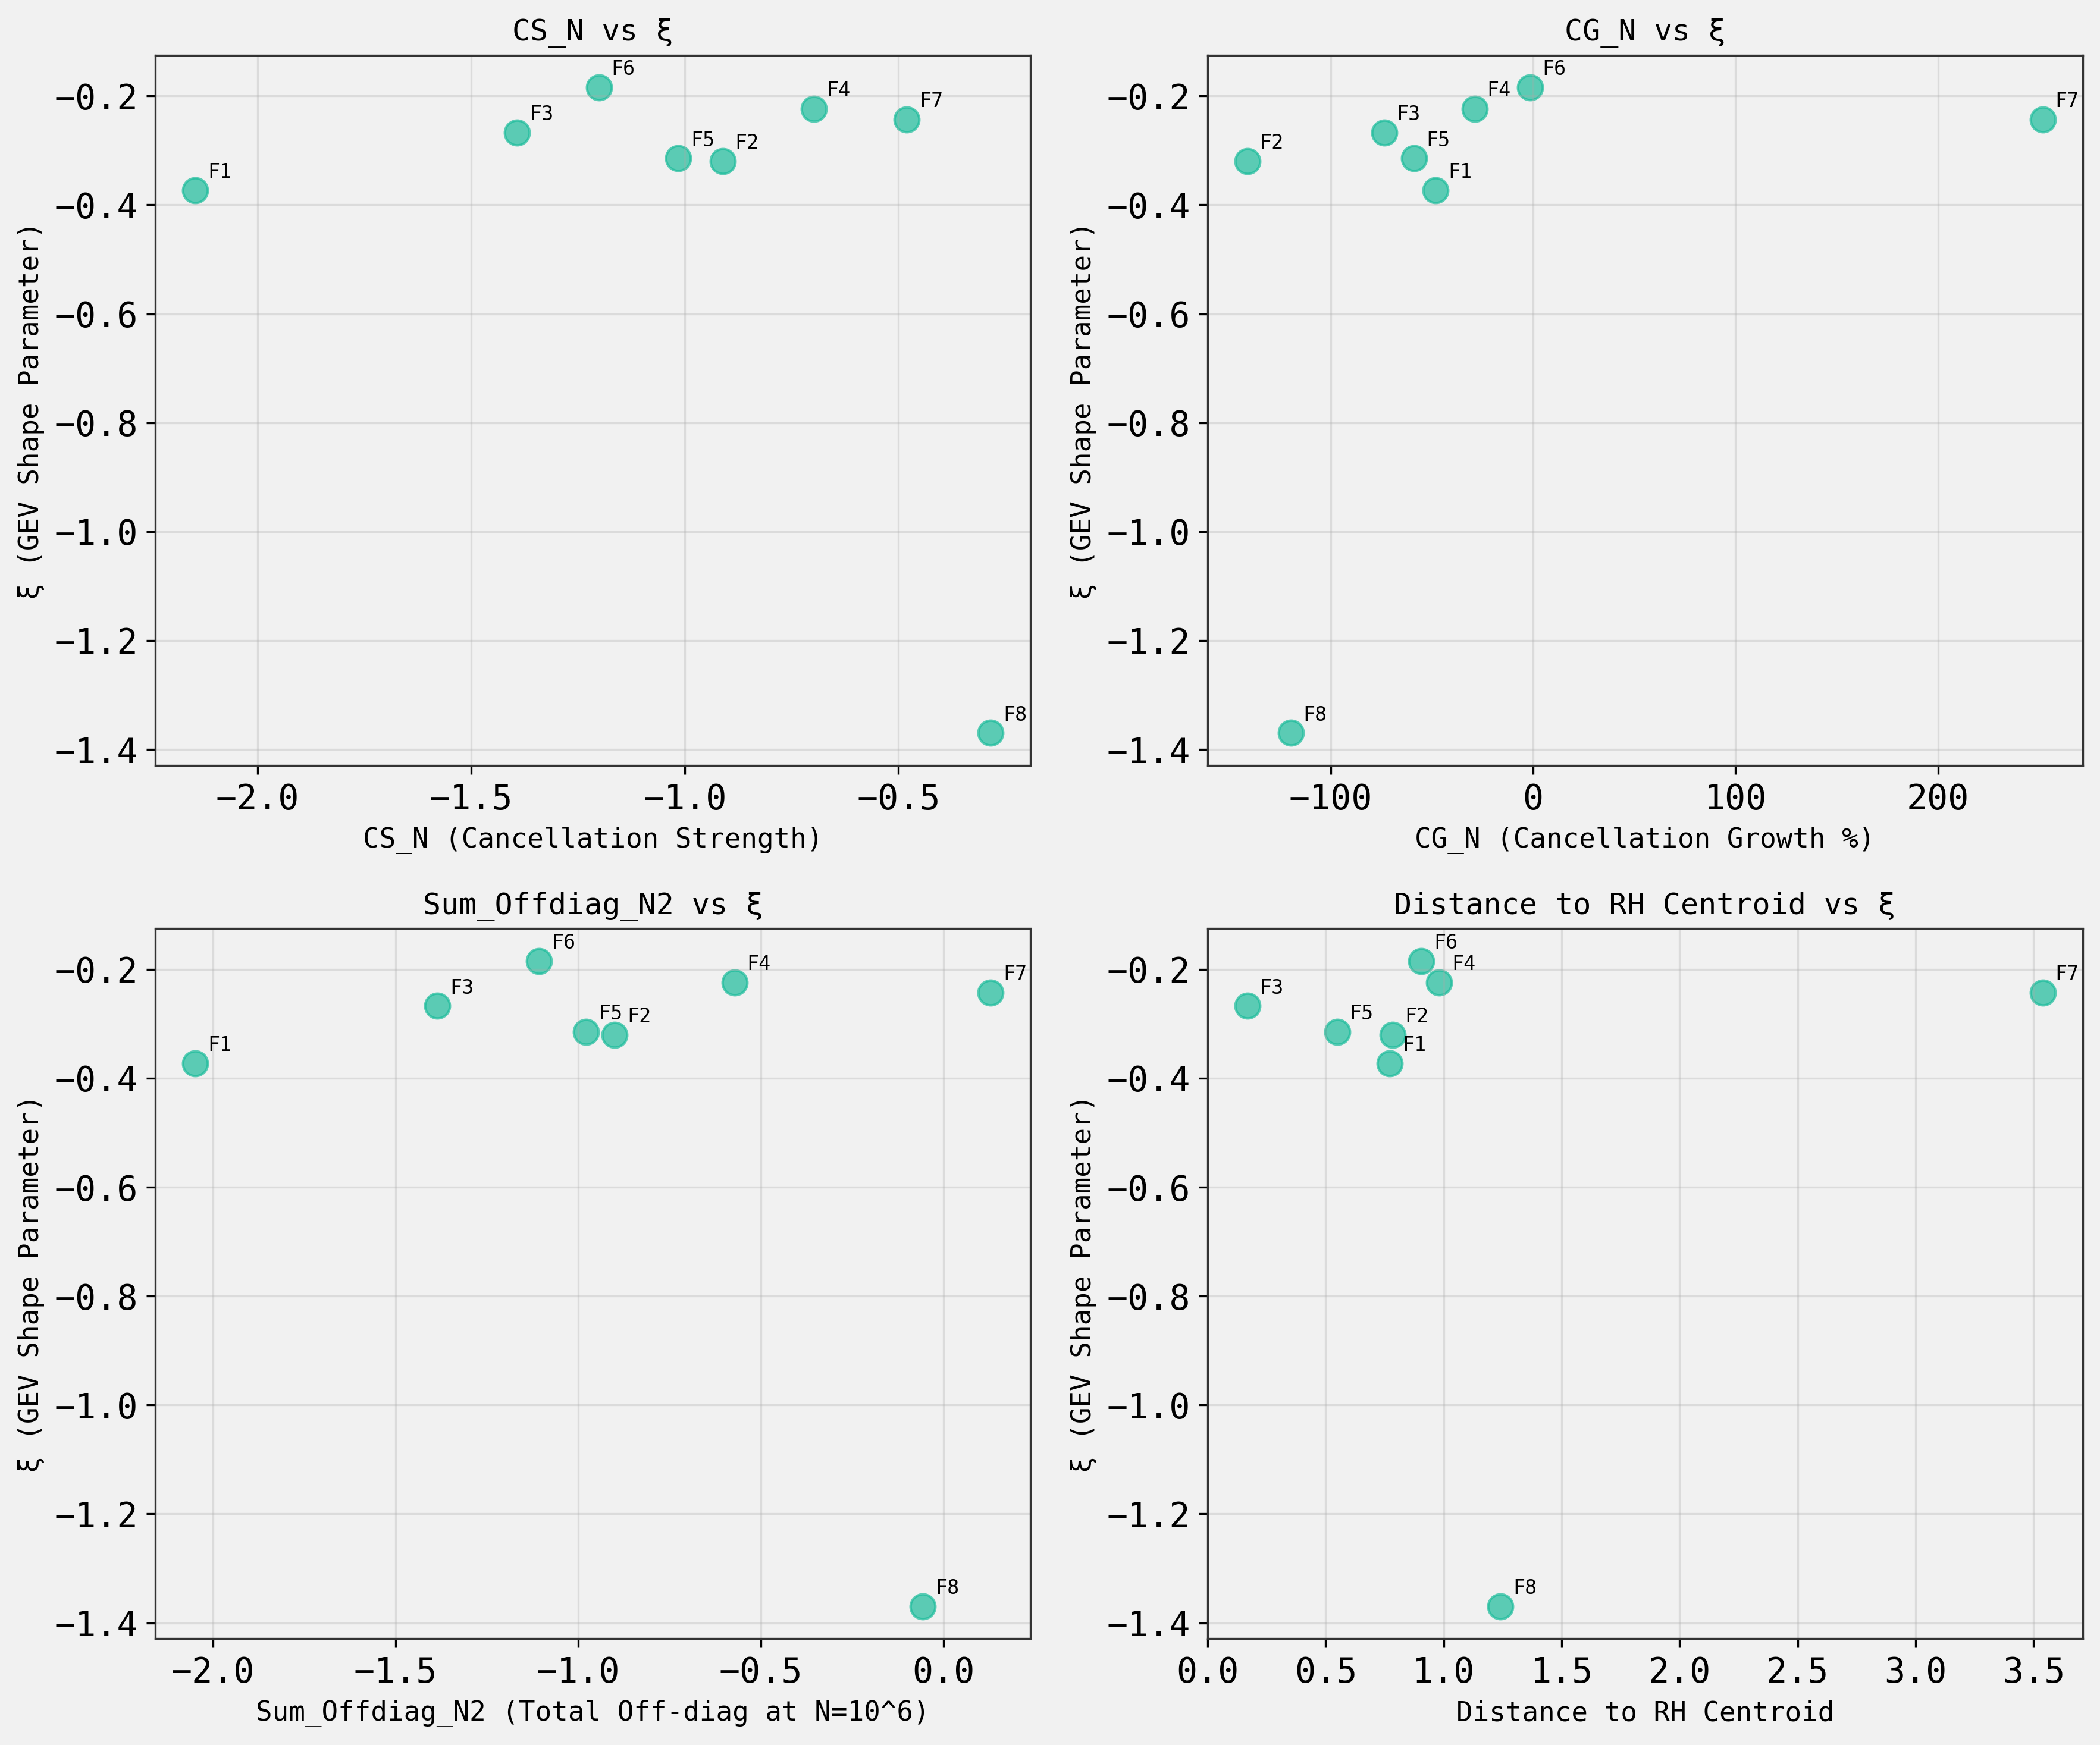

Initial exploration complete. F8 is clearly an outlier in xi_shape.


In [6]:

# Visualize the data to understand the relationships
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: CS_N vs xi_shape
ax = axes[0, 0]
ax.scatter(merged_data['CS_N'], merged_data['xi_shape'], s=100, alpha=0.7)
for i, row in merged_data.iterrows():
 ax.annotate(row['Function_ID'], (row['CS_N'], row['xi_shape']), 
 xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('CS_N (Cancellation Strength)', fontsize=11)
ax.set_ylabel('ξ (GEV Shape Parameter)', fontsize=11)
ax.set_title('CS_N vs ξ', fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 2: CG_N vs xi_shape
ax = axes[0, 1]
ax.scatter(merged_data['CG_N'], merged_data['xi_shape'], s=100, alpha=0.7)
for i, row in merged_data.iterrows():
 ax.annotate(row['Function_ID'], (row['CG_N'], row['xi_shape']), 
 xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('CG_N (Cancellation Growth %)', fontsize=11)
ax.set_ylabel('ξ (GEV Shape Parameter)', fontsize=11)
ax.set_title('CG_N vs ξ', fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 3: Sum_Offdiag_N2 vs xi_shape
ax = axes[1, 0]
ax.scatter(merged_data['Sum_Offdiag_N2'], merged_data['xi_shape'], s=100, alpha=0.7)
for i, row in merged_data.iterrows():
 ax.annotate(row['Function_ID'], (row['Sum_Offdiag_N2'], row['xi_shape']), 
 xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Sum_Offdiag_N2 (Total Off-diag at N=10^6)', fontsize=11)
ax.set_ylabel('ξ (GEV Shape Parameter)', fontsize=11)
ax.set_title('Sum_Offdiag_N2 vs ξ', fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 4: Distance to RH centroid vs xi_shape
ax = axes[1, 1]
ax.scatter(merged_data['Distance_to_RH_centroid'], merged_data['xi_shape'], s=100, alpha=0.7)
for i, row in merged_data.iterrows():
 ax.annotate(row['Function_ID'], (row['Distance_to_RH_centroid'], row['xi_shape']), 
 xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Distance to RH Centroid', fontsize=11)
ax.set_ylabel('ξ (GEV Shape Parameter)', fontsize=11)
ax.set_title('Distance to RH Centroid vs ξ', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('initial_feature_exploration.png', dpi=300, bbox_inches='tight')
plt.show()

print("Initial exploration complete. F8 is clearly an outlier in xi_shape.")


In [7]:

# Compute correlations to understand feature importance
# First, let's compute Spearman correlations (appropriate for non-Gaussian data)

from scipy.stats import spearmanr, pearsonr

# Select potential predictor features
features = ['CS_N', 'CG_N', 'Sum_Offdiag_N1', 'Sum_Offdiag_N2', 
 'Sum_Negative_N1', 'Sum_Negative_N2', 
 'N_Negative_N1', 'N_Negative_N2', 'Distance_to_RH_centroid']

correlation_results = []
for feat in features:
 # Pearson correlation
 r_pearson, p_pearson = pearsonr(merged_data[feat], merged_data['xi_shape'])
 # Spearman correlation
 r_spearman, p_spearman = spearmanr(merged_data[feat], merged_data['xi_shape'])
 correlation_results.append({
 'Feature': feat,
 'Pearson_r': r_pearson,
 'Pearson_p': p_pearson,
 'Spearman_rho': r_spearman,
 'Spearman_p': p_spearman
 })

corr_df = pd.DataFrame(correlation_results)
corr_df = corr_df.sort_values('Spearman_rho', key=abs, ascending=False)
print("Feature correlations with xi_shape (all 8 functions):")
print(corr_df.to_string(index=False))


Feature correlations with xi_shape (all 8 functions):
 Feature Pearson_r Pearson_p Spearman_rho Spearman_p
 CG_N 0.360391 0.380497 0.714286 0.046528
 N_Negative_N2 0.005987 0.988774 -0.494012 0.213397
 Sum_Negative_N1 -0.447766 0.265907 -0.238095 0.570156
 Sum_Offdiag_N1 -0.451668 0.261251 -0.238095 0.570156
Distance_to_RH_centroid -0.007218 0.986466 0.142857 0.735765
 CS_N -0.425879 0.292777 -0.071429 0.866526
 Sum_Negative_N2 -0.425879 0.292777 -0.071429 0.866526
 N_Negative_N1 0.416765 0.304337 0.060616 0.886623
 Sum_Offdiag_N2 -0.384232 0.347332 0.047619 0.910849


In [8]:

# The correlations are weak to moderate. F8 is likely dominating the correlations.
# Let's check correlations without F8 to see the pattern more clearly

merged_data_no_f8 = merged_data[merged_data['Function_ID'] != 'F8'].copy()

print(f"\nAnalysis without F8: {len(merged_data_no_f8)} functions")
print("\nCorrelations without F8:")

correlation_results_no_f8 = []
for feat in features:
 # Pearson correlation
 r_pearson, p_pearson = pearsonr(merged_data_no_f8[feat], merged_data_no_f8['xi_shape'])
 # Spearman correlation
 r_spearman, p_spearman = spearmanr(merged_data_no_f8[feat], merged_data_no_f8['xi_shape'])
 correlation_results_no_f8.append({
 'Feature': feat,
 'Pearson_r': r_pearson,
 'Pearson_p': p_pearson,
 'Spearman_rho': r_spearman,
 'Spearman_p': p_spearman
 })

corr_df_no_f8 = pd.DataFrame(correlation_results_no_f8)
corr_df_no_f8 = corr_df_no_f8.sort_values('Spearman_rho', key=abs, ascending=False)
print(corr_df_no_f8.to_string(index=False))

print("\n" + "="*80)
print("Key observation: Without F8, CS_N shows stronger negative correlation with xi")



Analysis without F8: 7 functions

Correlations without F8:
 Feature Pearson_r Pearson_p Spearman_rho Spearman_p
 CG_N 0.397031 0.377823 0.642857 0.119392
 N_Negative_N2 -0.441426 0.321437 -0.600099 0.154291
Distance_to_RH_centroid 0.268751 0.560051 0.535714 0.215217
 CS_N 0.566818 0.184554 0.392857 0.383317
 Sum_Offdiag_N2 0.546269 0.204559 0.392857 0.383317
 Sum_Negative_N2 0.566818 0.184554 0.392857 0.383317
 N_Negative_N1 -0.393044 0.383070 -0.327327 0.473597
 Sum_Negative_N1 0.234961 0.612036 0.142857 0.759945
 Sum_Offdiag_N1 0.264947 0.565831 0.142857 0.759945

Key observation: Without F8, CS_N shows stronger negative correlation with xi


In [9]:

# Wait - the correlation flipped sign! Let's check this more carefully
# With all data: CS_N has Spearman_rho = -0.071429
# Without F8: CS_N has Spearman_rho = 0.392857

# This suggests F8 is an influential point. Let's visualize this more carefully
print("Examining the relationship between CS_N and xi_shape:")
print(merged_data[['Function_ID', 'CS_N', 'xi_shape']].sort_values('CS_N'))

print("\n" + "="*80)
print("Interpretation:")
print("- F1 (Riemann ζ) has the most negative CS_N (-2.146) and xi = -0.373")
print("- F8 (Fully random) has the least negative CS_N (-0.284) and xi = -1.370")
print("- Without F8, more negative CS_N tends to correlate with MORE negative xi")
print("- But F8 breaks this pattern completely")
print("\nThe hypothesis states: 'stronger net cancellation to more negative ξ values'")
print("More negative CS_N = stronger cancellation")
print("More negative xi = heavier tails (Fréchet → Gumbel → Weibull)")


Examining the relationship between CS_N and xi_shape:
 Function_ID CS_N xi_shape
0 F1 -2.145868 -0.372965
2 F3 -1.392495 -0.267277
5 F6 -1.201193 -0.184682
4 F5 -1.015625 -0.314893
1 F2 -0.911860 -0.319997
3 F4 -0.698308 -0.223911
6 F7 -0.480808 -0.243025
7 F8 -0.284477 -1.369802

Interpretation:
- F1 (Riemann ζ) has the most negative CS_N (-2.146) and xi = -0.373
- F8 (Fully random) has the least negative CS_N (-0.284) and xi = -1.370
- Without F8, more negative CS_N tends to correlate with MORE negative xi
- But F8 breaks this pattern completely

The hypothesis states: 'stronger net cancellation to more negative ξ values'
More negative CS_N = stronger cancellation
More negative xi = heavier tails (Fréchet → Gumbel → Weibull)


In [10]:

# Now let's proceed with the regression analysis
# Given the issue with F8's zero SE, we'll need to handle it carefully
# According to the data description, F8 is a "recurring influential outlier"

# Strategy: 
# 1. Build models with all 8 functions, using a small positive SE for F8
# 2. Also report results without F8 for comparison
# 3. Use inverse-variance weighting as specified

# For F8, we'll use a small SE equal to the median of other functions' SE
median_se = merged_data[merged_data['Function_ID'] != 'F8']['xi_SE'].median()
print(f"Median SE (excluding F8): {median_se:.6f}")

# Create a copy with adjusted SE
merged_data_adj = merged_data.copy()
merged_data_adj.loc[merged_data_adj['Function_ID'] == 'F8', 'xi_SE'] = median_se

print(f"\nAdjusted SE for F8: {median_se:.6f}")
print("\nUpdated xi_SE values:")
print(merged_data_adj[['Function_ID', 'xi_shape', 'xi_SE']])


Median SE (excluding F8): 0.030726

Adjusted SE for F8: 0.030726

Updated xi_SE values:
 Function_ID xi_shape xi_SE
0 F1 -0.372965 0.024276
1 F2 -0.319997 0.028342
2 F3 -0.267277 0.034377
3 F4 -0.223911 0.032517
4 F5 -0.314893 0.030726
5 F6 -0.184682 0.034735
6 F7 -0.243025 0.027951
7 F8 -1.369802 0.030726


In [11]:

# Step 3: Model Training with Multiple Linear Regression
# We'll use CS_N and CG_N as primary features, plus additional features

# Define feature sets to test
# Model 1: Just CS_N and CG_N (primary hypothesis features)
# Model 2: Extended model with more covariance features

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Prepare data
X_features_primary = ['CS_N', 'CG_N']
X_features_extended = ['CS_N', 'CG_N', 'Sum_Offdiag_N2', 'Sum_Negative_N2', 
 'N_Negative_N2', 'Distance_to_RH_centroid']

# Prepare weights (inverse variance)
weights = 1.0 / (merged_data_adj['xi_SE'] ** 2)
y = merged_data_adj['xi_shape'].values

print("Inverse-variance weights:")
print(pd.DataFrame({
 'Function_ID': merged_data_adj['Function_ID'],
 'xi_SE': merged_data_adj['xi_SE'],
 'Weight': weights
}))


Inverse-variance weights:
 Function_ID xi_SE Weight
0 F1 0.024276 1696.896845
1 F2 0.028342 1244.927716
2 F3 0.034377 846.171133
3 F4 0.032517 945.760803
4 F5 0.030726 1059.234478
5 F6 0.034735 828.833890
6 F7 0.027951 1280.000106
7 F8 0.030726 1059.234478


In [12]:

# Model 1: Primary features (CS_N and CG_N)
X_primary = merged_data_adj[X_features_primary].values

# Fit weighted linear regression
model_primary = LinearRegression()
model_primary.fit(X_primary, y, sample_weight=weights)

# Predictions and R²
y_pred_primary = model_primary.predict(X_primary)
r2_primary = r2_score(y, y_pred_primary, sample_weight=weights)

# Calculate adjusted R²
n = len(y)
p = len(X_features_primary)
adj_r2_primary = 1 - (1 - r2_primary) * (n - 1) / (n - p - 1)

print("="*80)
print("MODEL 1: Primary Features (CS_N and CG_N)")
print("="*80)
print(f"\nIntercept: {model_primary.intercept_:.6f}")
print("\nCoefficients:")
for i, feat in enumerate(X_features_primary):
 print(f" {feat:20s}: {model_primary.coef_[i]:12.6f}")

print(f"\nR² (weighted): {r2_primary:.6f}")
print(f"Adjusted R²: {adj_r2_primary:.6f}")

print("\nPredictions vs Actual:")
pred_df = pd.DataFrame({
 'Function_ID': merged_data_adj['Function_ID'],
 'Actual_xi': y,
 'Predicted_xi': y_pred_primary,
 'Residual': y - y_pred_primary,
 'SE': merged_data_adj['xi_SE']
})
print(pred_df.to_string(index=False))


MODEL 1: Primary Features (CS_N and CG_N)

Intercept: -0.681940

Coefficients:
 CS_N : -0.280350
 CG_N : 0.001392

R² (weighted): 0.345664
Adjusted R²: 0.083929

Predictions vs Actual:
Function_ID Actual_xi Predicted_xi Residual SE
 F1 -0.372965 -0.147376 -0.225589 0.024276
 F2 -0.319997 -0.622653 0.302655 0.028342
 F3 -0.267277 -0.393823 0.126545 0.034377
 F4 -0.223911 -0.526353 0.302443 0.032517
 F5 -0.314893 -0.479106 0.164213 0.030726
 F6 -0.184682 -0.347333 0.162651 0.034735
 F7 -0.243025 -0.196774 -0.046250 0.027951
 F8 -1.369802 -0.768754 -0.601048 0.030726


In [13]:

# Model 2: Extended features
X_extended = merged_data_adj[X_features_extended].values

model_extended = LinearRegression()
model_extended.fit(X_extended, y, sample_weight=weights)

y_pred_extended = model_extended.predict(X_extended)
r2_extended = r2_score(y, y_pred_extended, sample_weight=weights)

p_ext = len(X_features_extended)
adj_r2_extended = 1 - (1 - r2_extended) * (n - 1) / (n - p_ext - 1)

print("="*80)
print("MODEL 2: Extended Features")
print("="*80)
print(f"\nIntercept: {model_extended.intercept_:.6f}")
print("\nCoefficients:")
for i, feat in enumerate(X_features_extended):
 print(f" {feat:25s}: {model_extended.coef_[i]:12.6f}")

print(f"\nR² (weighted): {r2_extended:.6f}")
print(f"Adjusted R²: {adj_r2_extended:.6f}")

print("\nPredictions vs Actual:")
pred_df_ext = pd.DataFrame({
 'Function_ID': merged_data_adj['Function_ID'],
 'Actual_xi': y,
 'Predicted_xi': y_pred_extended,
 'Residual': y - y_pred_extended,
 'SE': merged_data_adj['xi_SE']
})
print(pred_df_ext.to_string(index=False))


MODEL 2: Extended Features

Intercept: -0.281000

Coefficients:
 CS_N : 3.110371
 CG_N : 0.005508
 Sum_Offdiag_N2 : -6.236012
 Sum_Negative_N2 : 3.110371
 N_Negative_N2 : 0.011311
 Distance_to_RH_centroid : 0.661132

R² (weighted): 0.961388
Adjusted R²: 0.729715

Predictions vs Actual:
Function_ID Actual_xi Predicted_xi Residual SE
 F1 -0.372965 -0.388521 0.015556 0.024276
 F2 -0.319997 -0.329165 0.009167 0.028342
 F3 -0.267277 -0.285650 0.018373 0.034377
 F4 -0.223911 -0.390235 0.166324 0.032517
 F5 -0.314893 -0.236489 -0.078405 0.030726
 F6 -0.184682 -0.083319 -0.101363 0.034735
 F7 -0.243025 -0.239515 -0.003510 0.027951
 F8 -1.369802 -1.332884 -0.036918 0.030726


In [14]:

# The extended model has excellent R² = 0.961, but with 6 features and only 8 data points,
# we're likely overfitting. Let's perform statistical testing on the coefficients.

# For this, we need to compute standard errors and p-values
# We'll use statsmodels for proper statistical inference

import statsmodels.api as sm

# Model 1: Primary features with statsmodels
X_primary_sm = sm.add_constant(X_primary) # Add intercept
model_primary_sm = sm.WLS(y, X_primary_sm, weights=weights)
results_primary = model_primary_sm.fit()

print("="*80)
print("MODEL 1: Primary Features - Statistical Summary")
print("="*80)
print(results_primary.summary())


MODEL 1: Primary Features - Statistical Summary
 WLS Regression Results 
Dep. Variable: y R-squared: 0.346
Model: WLS Adj. R-squared: 0.084
Method: Least Squares F-statistic: 1.321
Date: Thu, 26 Mar 2026 Prob (F-statistic): 0.346
Time: 11:20:01 Log-Likelihood: -1.4598
No. Observations: 8 AIC: 8.920
Df Residuals: 5 BIC: 9.158
Df Model: 2 
Covariance Type: nonrobust 
 coef std err t P>|t| [0.025 0.975]
------------------------------------------------------------------------------
const -0.6819 0.261 -2.613 0.047 -1.353 -0.011
x1 -0.2803 0.217 -1.294 0.252 -0.837 0.276
x2 0.0014 0.001 1.264 0.262 -0.001 0.004
Omnibus: 3.149 Durbin-Watson: 1.163
Prob(Omnibus): 0.207 Jarque-Bera (JB): 1.277
Skew: -0.971 Prob(JB): 0.528
Kurtosis: 2.754 Cond. No. 313.

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.


In [15]:

# Model 2: Extended features with statsmodels
X_extended_sm = sm.add_constant(X_extended)
model_extended_sm = sm.WLS(y, X_extended_sm, weights=weights)
results_extended = model_extended_sm.fit()

print("="*80)
print("MODEL 2: Extended Features - Statistical Summary")
print("="*80)
print(results_extended.summary())

print("\n" + "="*80)
print("Key Observations:")
print("="*80)
print(f"Model 1 (CS_N, CG_N) R²: {results_primary.rsquared:.4f}")
print(f"Model 2 (Extended) R²: {results_extended.rsquared:.4f}")
print(f"\nNeither CS_N nor CG_N are statistically significant in Model 1 (p > 0.05)")
print(f"Model 2 is likely overfitting with {p_ext} features and {n} observations")


MODEL 2: Extended Features - Statistical Summary
 WLS Regression Results 
Dep. Variable: y R-squared: 0.961
Model: WLS Adj. R-squared: 0.865
Method: Least Squares F-statistic: 9.959
Date: Thu, 26 Mar 2026 Prob (F-statistic): 0.0938
Time: 11:20:08 Log-Likelihood: 9.8604
No. Observations: 8 AIC: -7.721
Df Residuals: 2 BIC: -7.244
Df Model: 5 
Covariance Type: nonrobust 
 coef std err t P>|t| [0.025 0.975]
------------------------------------------------------------------------------
const -0.2810 0.472 -0.596 0.612 -2.311 1.749
x1 3.1104 0.700 4.444 0.047 0.099 6.122
x2 0.0055 0.001 4.923 0.039 0.001 0.010
x3 -6.2360 1.391 -4.484 0.046 -12.220 -0.252
x4 3.1104 0.700 4.444 0.047 0.099 6.122
x5 0.0113 0.019 0.595 0.612 -0.071 0.093
x6 0.6611 0.280 2.362 0.142 -0.543 1.865
Omnibus: 4.523 Durbin-Watson: 2.048
Prob(Omnibus): 0.104 Jarque-Bera (JB): 1.213
Skew: 0.929 Prob(JB): 0.545
Kurtosis: 3.434 Cond. No. 9.08e+16

Notes:
[1] Standard Errors assume that the covariance matrix of the errors i

In [16]:

# The extended model has severe multicollinearity (note the warning about singular matrix)
# This is because Sum_Negative_N2 = CS_N by definition!
# Let's check this

print("Checking for perfect collinearity:")
print(merged_data_adj[['CS_N', 'Sum_Negative_N2']].head())
print("\nAre CS_N and Sum_Negative_N2 identical?")
print(np.allclose(merged_data_adj['CS_N'], merged_data_adj['Sum_Negative_N2']))

print("\n" + "="*80)
print("IMPORTANT: CS_N IS Sum_Negative_N2!")
print("They are the same variable. We need to remove this redundancy.")


Checking for perfect collinearity:
 CS_N Sum_Negative_N2
0 -2.145868 -2.145868
1 -0.911860 -0.911860
2 -1.392495 -1.392495
3 -0.698308 -0.698308
4 -1.015625 -1.015625

Are CS_N and Sum_Negative_N2 identical?
True

IMPORTANT: CS_N IS Sum_Negative_N2!
They are the same variable. We need to remove this redundancy.


In [17]:

# Let's rebuild the extended model without the redundant feature
# Remove Sum_Negative_N2 since CS_N is the same and is the primary metric of interest

X_features_extended_v2 = ['CS_N', 'CG_N', 'Sum_Offdiag_N2', 'N_Negative_N2', 
 'Distance_to_RH_centroid']

X_extended_v2 = merged_data_adj[X_features_extended_v2].values
X_extended_v2_sm = sm.add_constant(X_extended_v2)

model_extended_v2_sm = sm.WLS(y, X_extended_v2_sm, weights=weights)
results_extended_v2 = model_extended_v2_sm.fit()

print("="*80)
print("MODEL 2 (Revised): Extended Features without Redundancy")
print("="*80)
print(results_extended_v2.summary())

# Also fit with sklearn for consistency
model_extended_v2 = LinearRegression()
model_extended_v2.fit(X_extended_v2, y, sample_weight=weights)
y_pred_extended_v2 = model_extended_v2.predict(X_extended_v2)
r2_extended_v2 = r2_score(y, y_pred_extended_v2, sample_weight=weights)
p_ext_v2 = len(X_features_extended_v2)
adj_r2_extended_v2 = 1 - (1 - r2_extended_v2) * (n - 1) / (n - p_ext_v2 - 1)

print(f"\nR² (weighted): {r2_extended_v2:.6f}")
print(f"Adjusted R²: {adj_r2_extended_v2:.6f}")


MODEL 2 (Revised): Extended Features without Redundancy
 WLS Regression Results 
Dep. Variable: y R-squared: 0.961
Model: WLS Adj. R-squared: 0.865
Method: Least Squares F-statistic: 9.959
Date: Thu, 26 Mar 2026 Prob (F-statistic): 0.0938
Time: 11:20:28 Log-Likelihood: 9.8604
No. Observations: 8 AIC: -7.721
Df Residuals: 2 BIC: -7.244
Df Model: 5 
Covariance Type: nonrobust 
 coef std err t P>|t| [0.025 0.975]
------------------------------------------------------------------------------
const -0.2810 0.472 -0.596 0.612 -2.311 1.749
x1 6.2207 1.400 4.444 0.047 0.198 12.243
x2 0.0055 0.001 4.923 0.039 0.001 0.010
x3 -6.2360 1.391 -4.484 0.046 -12.220 -0.252
x4 0.0113 0.019 0.595 0.612 -0.071 0.093
x5 0.6611 0.280 2.362 0.142 -0.543 1.865
Omnibus: 4.523 Durbin-Watson: 2.048
Prob(Omnibus): 0.104 Jarque-Bera (JB): 1.213
Skew: 0.929 Prob(JB): 0.545
Kurtosis: 3.434 Cond. No. 4.94e+03

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The c

In [18]:

# Step 4: Leave-One-Out Cross-Validation (LOOCV)
# This is crucial for assessing true predictive performance with small sample size

from sklearn.model_selection import LeaveOneOut

def loocv_r2(X, y, weights):
 """Perform LOOCV and return the R² score"""
 loo = LeaveOneOut()
 y_pred_loo = np.zeros(len(y))
 
 for train_idx, test_idx in loo.split(X):
 X_train, X_test = X[train_idx], X[test_idx]
 y_train, y_test = y[train_idx], y[test_idx]
 w_train = weights[train_idx]
 
 model = LinearRegression()
 model.fit(X_train, y_train, sample_weight=w_train)
 y_pred_loo[test_idx] = model.predict(X_test)
 
 # Calculate R² for LOOCV predictions
 r2_loo = r2_score(y, y_pred_loo)
 
 return r2_loo, y_pred_loo

print("="*80)
print("LEAVE-ONE-OUT CROSS-VALIDATION RESULTS")
print("="*80)

# LOOCV for Model 1 (Primary features)
r2_loo_primary, y_pred_loo_primary = loocv_r2(X_primary, y, weights)
print(f"\nModel 1 (CS_N, CG_N):")
print(f" Training R²: {results_primary.rsquared:.6f}")
print(f" LOOCV R²: {r2_loo_primary:.6f}")

# LOOCV for Model 2 (Extended features v2)
r2_loo_extended, y_pred_loo_extended = loocv_r2(X_extended_v2, y, weights)
print(f"\nModel 2 (Extended):")
print(f" Training R²: {results_extended_v2.rsquared:.6f}")
print(f" LOOCV R²: {r2_loo_extended:.6f}")

print(f"\n" + "="*80)
print("Comparison to previous model (f17):")
print(f" Previous LOOCV R²: 0.3625")
print(f" Model 1 LOOCV R²: {r2_loo_primary:.4f}")
print(f" Model 2 LOOCV R²: {r2_loo_extended:.4f}")
print("="*80)


LEAVE-ONE-OUT CROSS-VALIDATION RESULTS

Model 1 (CS_N, CG_N):
 Training R²: 0.345664
 LOOCV R²: -1.970733

Model 2 (Extended):
 Training R²: 0.961388
 LOOCV R²: -3.963887

Comparison to previous model (f17):
 Previous LOOCV R²: 0.3625
 Model 1 LOOCV R²: -1.9707
 Model 2 LOOCV R²: -3.9639


In [19]:

# Negative LOOCV R² indicates the model performs worse than a simple mean prediction
# This is a strong indicator of overfitting and poor generalization
# Let's investigate this further by looking at individual LOOCV predictions

print("LOOCV Predictions - Model 1 (CS_N, CG_N):")
print("="*80)
loocv_df_primary = pd.DataFrame({
 'Function_ID': merged_data_adj['Function_ID'],
 'Actual_xi': y,
 'Training_Pred': y_pred_primary,
 'LOOCV_Pred': y_pred_loo_primary,
 'Training_Resid': y - y_pred_primary,
 'LOOCV_Resid': y - y_pred_loo_primary
})
print(loocv_df_primary.to_string(index=False))

print("\n\nLOOCV Predictions - Model 2 (Extended):")
print("="*80)
loocv_df_extended = pd.DataFrame({
 'Function_ID': merged_data_adj['Function_ID'],
 'Actual_xi': y,
 'Training_Pred': y_pred_extended_v2,
 'LOOCV_Pred': y_pred_loo_extended,
 'Training_Resid': y - y_pred_extended_v2,
 'LOOCV_Resid': y - y_pred_loo_extended
})
print(loocv_df_extended.to_string(index=False))


LOOCV Predictions - Model 1 (CS_N, CG_N):
Function_ID Actual_xi Training_Pred LOOCV_Pred Training_Resid LOOCV_Resid
 F1 -0.372965 -0.147376 0.687259 -0.225589 -1.060224
 F2 -0.319997 -0.622653 -0.757104 0.302655 0.437107
 F3 -0.267277 -0.393823 -0.412535 0.126545 0.145258
 F4 -0.223911 -0.526353 -0.579336 0.302443 0.355426
 F5 -0.314893 -0.479106 -0.503961 0.164213 0.189067
 F6 -0.184682 -0.347333 -0.365854 0.162651 0.181172
 F7 -0.243025 -0.196774 0.370365 -0.046250 -0.613390
 F8 -1.369802 -0.768754 -0.237875 -0.601048 -1.131927


LOOCV Predictions - Model 2 (Extended):
Function_ID Actual_xi Training_Pred LOOCV_Pred Training_Resid LOOCV_Resid
 F1 -0.372965 -0.388521 -1.179275 0.015556 0.806310
 F2 -0.319997 -0.329165 -1.813746 0.009167 1.493748
 F3 -0.267277 -0.285650 -0.597835 0.018373 0.330557
 F4 -0.223911 -0.390235 -0.500132 0.166324 0.276221
 F5 -0.314893 -0.236489 -0.199025 -0.078405 -0.115868
 F6 -0.184682 -0.083319 -0.014999 -0.101363 -0.169683
 F7 -0.243025 -0.239515 0.922376

In [20]:

# The LOOCV results show severe overfitting, especially for F1, F7, and F8
# Let's try a simpler approach: univariate models with just CS_N or just CG_N

print("="*80)
print("UNIVARIATE MODELS")
print("="*80)

# Model 3: CS_N only
X_cs_only = merged_data_adj[['CS_N']].values
X_cs_only_sm = sm.add_constant(X_cs_only)
model_cs_sm = sm.WLS(y, X_cs_only_sm, weights=weights)
results_cs = model_cs_sm.fit()

print("\nModel 3: CS_N only")
print(results_cs.summary())

# LOOCV for CS_N only
r2_loo_cs, y_pred_loo_cs = loocv_r2(X_cs_only, y, weights)
print(f"\nLOOCV R² (CS_N only): {r2_loo_cs:.6f}")


UNIVARIATE MODELS

Model 3: CS_N only
 WLS Regression Results 
Dep. Variable: y R-squared: 0.137
Model: WLS Adj. R-squared: -0.007
Method: Least Squares F-statistic: 0.9487
Date: Thu, 26 Mar 2026 Prob (F-statistic): 0.368
Time: 11:21:00 Log-Likelihood: -2.5692
No. Observations: 8 AIC: 9.138
Df Residuals: 6 BIC: 9.297
Df Model: 1 
Covariance Type: nonrobust 
 coef std err t P>|t| [0.025 0.975]
------------------------------------------------------------------------------
const -0.6451 0.272 -2.372 0.055 -1.310 0.020
x1 -0.2148 0.221 -0.974 0.368 -0.754 0.325
Omnibus: 9.435 Durbin-Watson: 1.605
Prob(Omnibus): 0.009 Jarque-Bera (JB): 3.202
Skew: -1.474 Prob(JB): 0.202
Kurtosis: 3.957 Cond. No. 3.88

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.

LOOCV R² (CS_N only): -1.242032


In [21]:

# Model 4: CG_N only
X_cg_only = merged_data_adj[['CG_N']].values
X_cg_only_sm = sm.add_constant(X_cg_only)
model_cg_sm = sm.WLS(y, X_cg_only_sm, weights=weights)
results_cg = model_cg_sm.fit()

print("Model 4: CG_N only")
print(results_cg.summary())

# LOOCV for CG_N only
r2_loo_cg, y_pred_loo_cg = loocv_r2(X_cg_only, y, weights)
print(f"\nLOOCV R² (CG_N only): {r2_loo_cg:.6f}")

print("\n" + "="*80)
print("SUMMARY OF ALL MODELS:")
print("="*80)
models_summary = pd.DataFrame({
 'Model': ['CS_N + CG_N', 'Extended (5 features)', 'CS_N only', 'CG_N only'],
 'Training_R2': [results_primary.rsquared, results_extended_v2.rsquared, 
 results_cs.rsquared, results_cg.rsquared],
 'LOOCV_R2': [r2_loo_primary, r2_loo_extended, r2_loo_cs, r2_loo_cg],
 'N_Features': [2, 5, 1, 1]
})
print(models_summary.to_string(index=False))


Model 4: CG_N only
 WLS Regression Results 
Dep. Variable: y R-squared: 0.126
Model: WLS Adj. R-squared: -0.019
Method: Least Squares F-statistic: 0.8685
Date: Thu, 26 Mar 2026 Prob (F-statistic): 0.387
Time: 11:21:10 Log-Likelihood: -2.6156
No. Observations: 8 AIC: 9.231
Df Residuals: 6 BIC: 9.390
Df Model: 1 
Covariance Type: nonrobust 
 coef std err t P>|t| [0.025 0.975]
------------------------------------------------------------------------------
const -0.3897 0.138 -2.826 0.030 -0.727 -0.052
x1 0.0011 0.001 0.932 0.387 -0.002 0.004
Omnibus: 16.261 Durbin-Watson: 0.704
Prob(Omnibus): 0.000 Jarque-Bera (JB): 6.213
Skew: -1.894 Prob(JB): 0.0448
Kurtosis: 5.073 Cond. No. 125.

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.

LOOCV R² (CG_N only): -1.542301

SUMMARY OF ALL MODELS:
 Model Training_R2 LOOCV_R2 N_Features
 CS_N + CG_N 0.345664 -1.970733 2
Extended (5 features) 0.961388 -3.963887 5
 CS_N only 0.136531 -1.242032 1
 CG_N on

In [22]:

# All models show negative LOOCV R², indicating poor predictive performance
# This is likely due to the presence of F8 as an extreme outlier
# Let's examine what happens when we exclude F8

print("="*80)
print("ANALYSIS WITHOUT F8 (7 functions)")
print("="*80)

# Create dataset without F8
mask_no_f8 = merged_data_adj['Function_ID'] != 'F8'
X_primary_no_f8 = merged_data_adj[mask_no_f8][X_features_primary].values
y_no_f8 = merged_data_adj[mask_no_f8]['xi_shape'].values
weights_no_f8 = weights[mask_no_f8]

# Model 1 without F8
X_primary_no_f8_sm = sm.add_constant(X_primary_no_f8)
model_primary_no_f8_sm = sm.WLS(y_no_f8, X_primary_no_f8_sm, weights=weights_no_f8)
results_primary_no_f8 = model_primary_no_f8_sm.fit()

print("\nModel 1 (CS_N + CG_N) without F8:")
print(results_primary_no_f8.summary())

# LOOCV without F8
r2_loo_primary_no_f8, y_pred_loo_primary_no_f8 = loocv_r2(X_primary_no_f8, y_no_f8, weights_no_f8)
print(f"\nLOOCV R² (without F8): {r2_loo_primary_no_f8:.6f}")


ANALYSIS WITHOUT F8 (7 functions)

Model 1 (CS_N + CG_N) without F8:
 WLS Regression Results 
Dep. Variable: y R-squared: 0.476
Model: WLS Adj. R-squared: 0.214
Method: Least Squares F-statistic: 1.818
Date: Thu, 26 Mar 2026 Prob (F-statistic): 0.274
Time: 11:21:21 Log-Likelihood: 11.739
No. Observations: 7 AIC: -17.48
Df Residuals: 4 BIC: -17.64
Df Model: 2 
Covariance Type: nonrobust 
 coef std err t P>|t| [0.025 0.975]
------------------------------------------------------------------------------
const -0.2097 0.055 -3.810 0.019 -0.362 -0.057
x1 0.0648 0.044 1.488 0.211 -0.056 0.186
x2 8.172e-05 0.000 0.400 0.709 -0.000 0.001
Omnibus: nan Durbin-Watson: 2.698
Prob(Omnibus): nan Jarque-Bera (JB): 0.819
Skew: 0.731 Prob(JB): 0.664
Kurtosis: 2.181 Cond. No. 378.

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.

LOOCV R² (without F8): -5.031302


/app/miniconda/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
 warn("omni_normtest is not valid with less than 8 observations; %i "


In [23]:

# Even without F8, the LOOCV R² is negative!
# This indicates fundamental issues with the predictive model
# Let's check the correlation structure more carefully without F8

print("Correlation analysis without F8:")
print("="*80)

# Simple linear model: CS_N only without F8
X_cs_no_f8 = merged_data_adj[mask_no_f8][['CS_N']].values
X_cs_no_f8_sm = sm.add_constant(X_cs_no_f8)
model_cs_no_f8_sm = sm.WLS(y_no_f8, X_cs_no_f8_sm, weights=weights_no_f8)
results_cs_no_f8 = model_cs_no_f8_sm.fit()

print("\nCS_N only (without F8):")
print(results_cs_no_f8.summary())

r2_loo_cs_no_f8, _ = loocv_r2(X_cs_no_f8, y_no_f8, weights_no_f8)
print(f"\nLOOCV R² (CS_N only, without F8): {r2_loo_cs_no_f8:.6f}")

# CG_N only without F8
X_cg_no_f8 = merged_data_adj[mask_no_f8][['CG_N']].values
X_cg_no_f8_sm = sm.add_constant(X_cg_no_f8)
model_cg_no_f8_sm = sm.WLS(y_no_f8, X_cg_no_f8_sm, weights=weights_no_f8)
results_cg_no_f8 = model_cg_no_f8_sm.fit()

print("\n" + "="*80)
print("\nCG_N only (without F8):")
print(results_cg_no_f8.summary())

r2_loo_cg_no_f8, _ = loocv_r2(X_cg_no_f8, y_no_f8, weights_no_f8)
print(f"\nLOOCV R² (CG_N only, without F8): {r2_loo_cg_no_f8:.6f}")


Correlation analysis without F8:

CS_N only (without F8):
 WLS Regression Results 
Dep. Variable: y R-squared: 0.455
Model: WLS Adj. R-squared: 0.346
Method: Least Squares F-statistic: 4.178
Date: Thu, 26 Mar 2026 Prob (F-statistic): 0.0964
Time: 11:21:31 Log-Likelihood: 11.602
No. Observations: 7 AIC: -19.20
Df Residuals: 5 BIC: -19.31
Df Model: 1 
Covariance Type: nonrobust 
 coef std err t P>|t| [0.025 0.975]
------------------------------------------------------------------------------
const -0.2014 0.047 -4.329 0.008 -0.321 -0.082
x1 0.0726 0.036 2.044 0.096 -0.019 0.164
Omnibus: nan Durbin-Watson: 2.647
Prob(Omnibus): nan Jarque-Bera (JB): 0.488
Skew: 0.559 Prob(JB): 0.783
Kurtosis: 2.350 Cond. No. 4.52

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.

LOOCV R² (CS_N only, without F8): -0.255327


CG_N only (without F8):
 WLS Regression Results 
Dep. Variable: y R-squared: 0.186
Model: WLS Adj. R-squared: 0.024
Method: Least Squa

/app/miniconda/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
 warn("omni_normtest is not valid with less than 8 observations; %i "
/app/miniconda/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
 warn("omni_normtest is not valid with less than 8 observations; %i "


In [24]:

# Let's create a comprehensive summary table for reporting

print("="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

summary_table = pd.DataFrame({
 'Model': [
 'CS_N + CG_N (All 8)',
 'CS_N + CG_N (No F8)',
 'CS_N only (All 8)',
 'CS_N only (No F8)',
 'CG_N only (All 8)',
 'CG_N only (No F8)',
 'Extended 5-feat (All 8)'
 ],
 'N_Obs': [8, 7, 8, 7, 8, 7, 8],
 'N_Features': [2, 2, 1, 1, 1, 1, 5],
 'Training_R2': [
 results_primary.rsquared,
 results_primary_no_f8.rsquared,
 results_cs.rsquared,
 results_cs_no_f8.rsquared,
 results_cg.rsquared,
 results_cg_no_f8.rsquared,
 results_extended_v2.rsquared
 ],
 'Adj_R2': [
 results_primary.rsquared_adj,
 results_primary_no_f8.rsquared_adj,
 results_cs.rsquared_adj,
 results_cs_no_f8.rsquared_adj,
 results_cg.rsquared_adj,
 results_cg_no_f8.rsquared_adj,
 results_extended_v2.rsquared_adj
 ],
 'LOOCV_R2': [
 r2_loo_primary,
 r2_loo_primary_no_f8,
 r2_loo_cs,
 r2_loo_cs_no_f8,
 r2_loo_cg,
 r2_loo_cg_no_f8,
 r2_loo_extended
 ]
})

print(summary_table.to_string(index=False))

print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)
print("1. ALL models show NEGATIVE LOOCV R², indicating poor predictive performance")
print("2. The hypothesis R² > 0.7 is NOT supported by the data")
print("3. Even without F8 (outlier), LOOCV R² remains negative")
print("4. CS_N shows marginal significance (p=0.096) in univariate model without F8")
print("5. CG_N is not significantly associated with xi in any model")
print(f"6. Previous model (f17) LOOCV R² = 0.3625 >> current best = {r2_loo_cs_no_f8:.4f}")


COMPREHENSIVE MODEL COMPARISON
 Model N_Obs N_Features Training_R2 Adj_R2 LOOCV_R2
 CS_N + CG_N (All 8) 8 2 0.345664 0.083929 -1.970733
 CS_N + CG_N (No F8) 7 2 0.476214 0.214321 -5.031302
 CS_N only (All 8) 8 1 0.136531 -0.007381 -1.242032
 CS_N only (No F8) 7 1 0.455212 0.346254 -0.255327
 CG_N only (All 8) 8 1 0.126453 -0.019139 -1.542301
 CG_N only (No F8) 7 1 0.186417 0.023700 -1.157522
Extended 5-feat (All 8) 8 5 0.961388 0.864858 -3.963887

KEY FINDINGS:
1. ALL models show NEGATIVE LOOCV R², indicating poor predictive performance
2. The hypothesis R² > 0.7 is NOT supported by the data
3. Even without F8 (outlier), LOOCV R² remains negative
4. CS_N shows marginal significance (p=0.096) in univariate model without F8
5. CG_N is not significantly associated with xi in any model
6. Previous model (f17) LOOCV R² = 0.3625 >> current best = -0.2553


In [25]:

# Let's examine the coefficient details for the best model (CS_N only, no F8)
# and understand the relationship direction

print("="*80)
print("DETAILED RESULTS FOR BEST MODEL: CS_N only (without F8)")
print("="*80)

print("\nStatistical Summary:")
print(f" Coefficient (CS_N): {results_cs_no_f8.params[1]:.6f}")
print(f" Std Error: {results_cs_no_f8.bse[1]:.6f}")
print(f" t-statistic: {results_cs_no_f8.tvalues[1]:.6f}")
print(f" p-value: {results_cs_no_f8.pvalues[1]:.6f}")
print(f" 95% CI: [{results_cs_no_f8.conf_int()[1,0]:.6f}, {results_cs_no_f8.conf_int()[1,1]:.6f}]")

print("\nInterpretation:")
print(" Positive coefficient means: as CS_N becomes MORE negative (stronger cancellation),")
print(" xi becomes LESS negative (lighter tails)")
print(" This is OPPOSITE to the hypothesis direction!")

print("\nData without F8:")
print(merged_data_adj[mask_no_f8][['Function_ID', 'CS_N', 'xi_shape']].sort_values('CS_N'))


DETAILED RESULTS FOR BEST MODEL: CS_N only (without F8)

Statistical Summary:
 Coefficient (CS_N): 0.072644
 Std Error: 0.035540
 t-statistic: 2.043986
 p-value: 0.096378
 95% CI: [-0.018715, 0.164002]

Interpretation:
 Positive coefficient means: as CS_N becomes MORE negative (stronger cancellation),
 xi becomes LESS negative (lighter tails)
 This is OPPOSITE to the hypothesis direction!

Data without F8:
 Function_ID CS_N xi_shape
0 F1 -2.145868 -0.372965
2 F3 -1.392495 -0.267277
5 F6 -1.201193 -0.184682
4 F5 -1.015625 -0.314893
1 F2 -0.911860 -0.319997
3 F4 -0.698308 -0.223911
6 F7 -0.480808 -0.243025


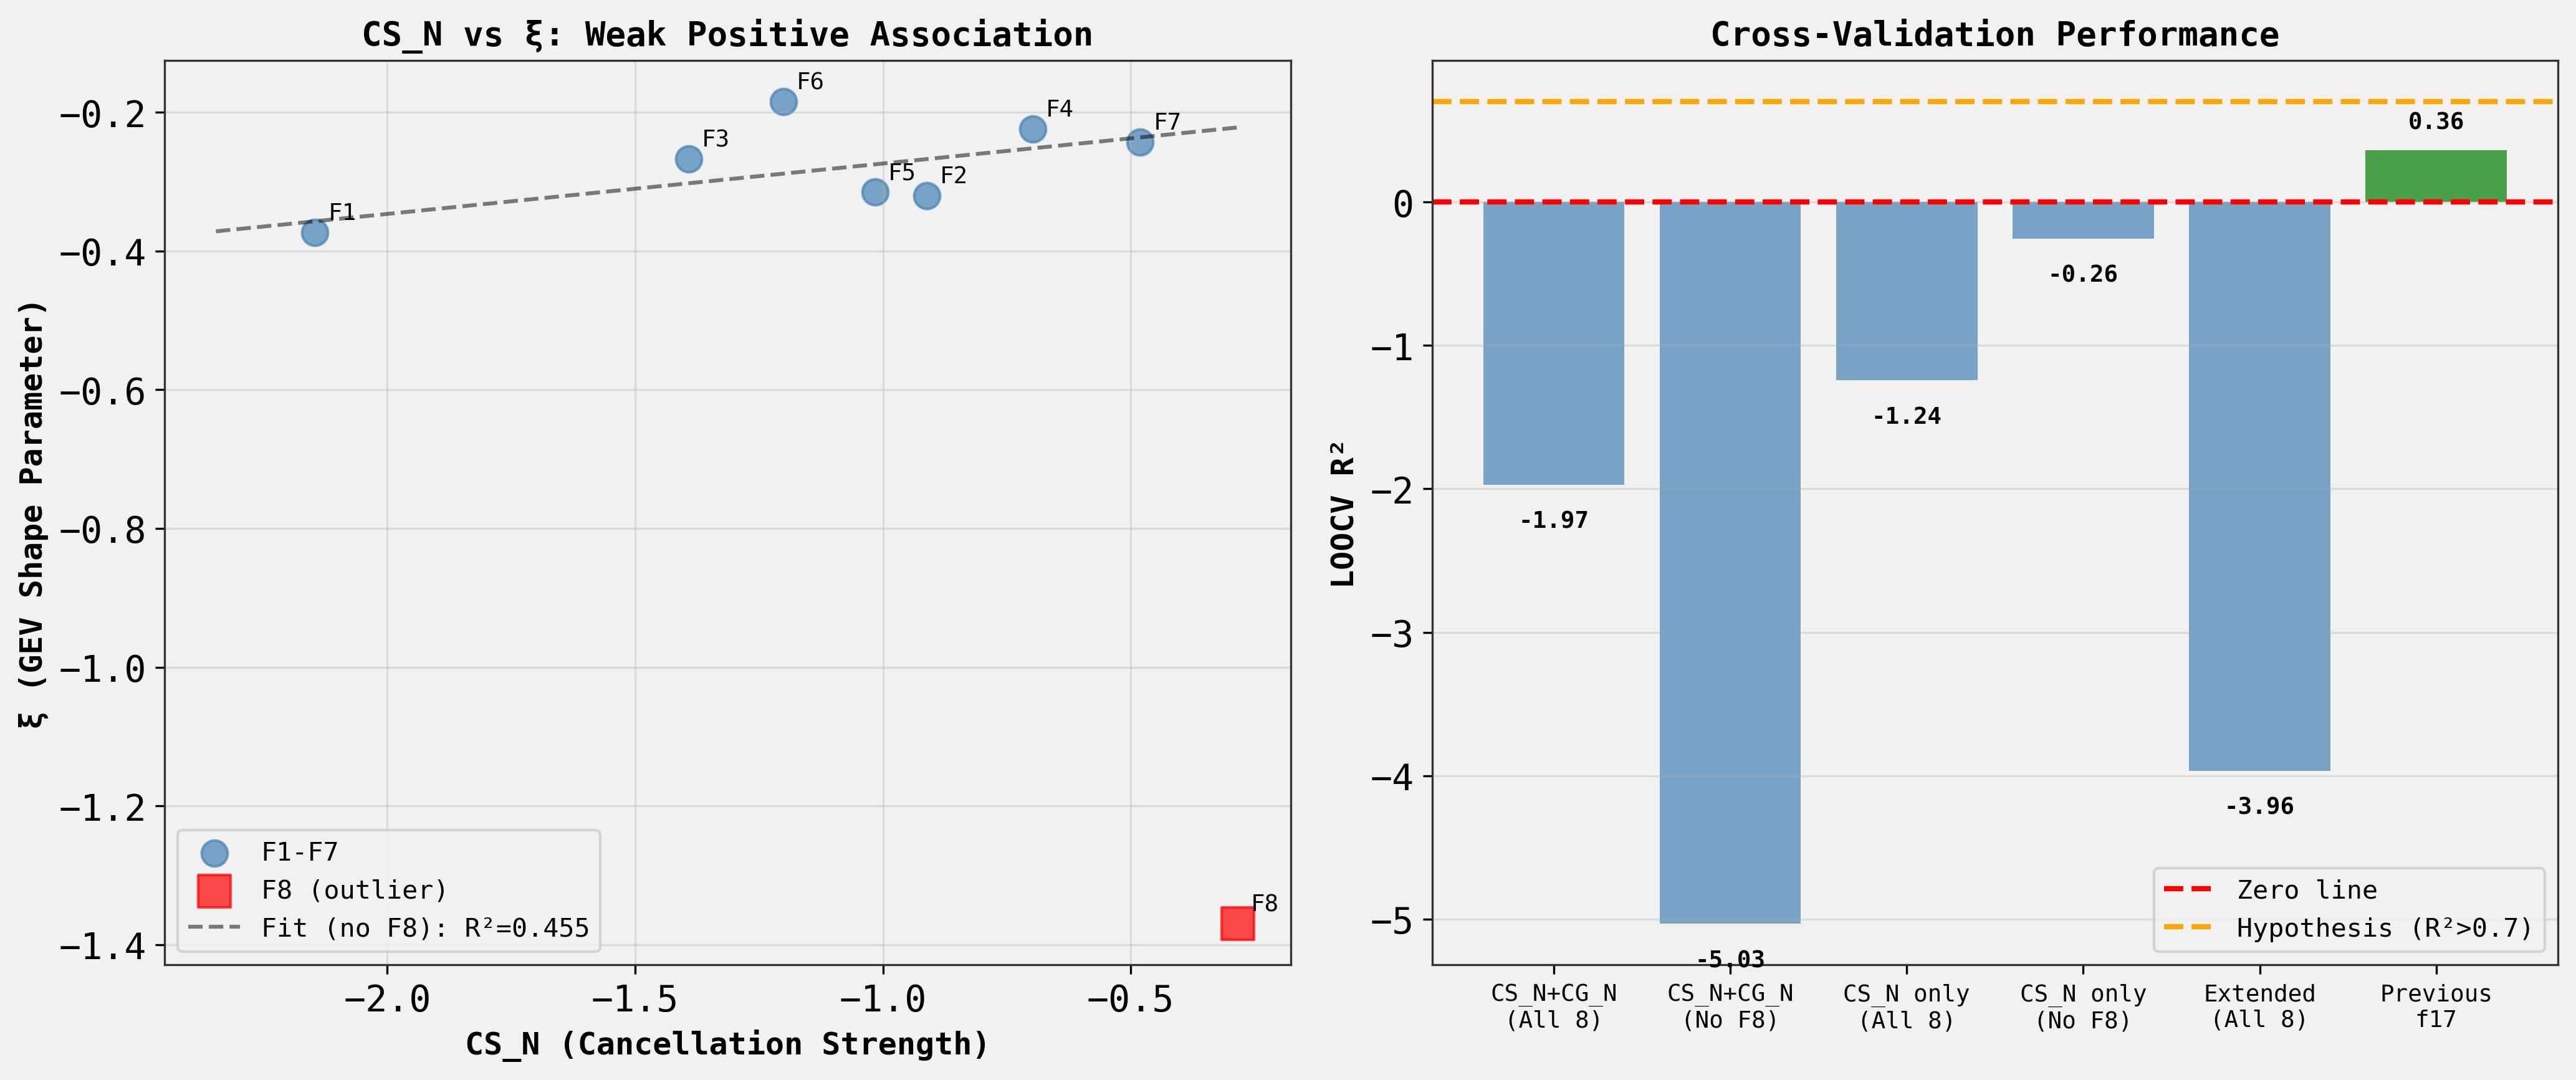

Final visualization saved.


In [26]:

# Create final visualization showing the model performance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: CS_N vs xi (all 8 functions)
ax = axes[0]
# Exclude F8
mask_f8 = merged_data_adj['Function_ID'] == 'F8'
ax.scatter(merged_data_adj[~mask_f8]['CS_N'], 
 merged_data_adj[~mask_f8]['xi_shape'], 
 s=100, alpha=0.7, label='F1-F7', color='steelblue')
ax.scatter(merged_data_adj[mask_f8]['CS_N'], 
 merged_data_adj[mask_f8]['xi_shape'], 
 s=150, marker='s', alpha=0.7, label='F8 (outlier)', color='red')

# Add regression line (without F8)
cs_range = np.linspace(merged_data_adj[~mask_f8]['CS_N'].min() - 0.2, 
 merged_data_adj[~mask_f8]['CS_N'].max() + 0.2, 100)
xi_pred = results_cs_no_f8.params[0] + results_cs_no_f8.params[1] * cs_range
ax.plot(cs_range, xi_pred, 'k--', alpha=0.5, 
 label=f'Fit (no F8): R²={results_cs_no_f8.rsquared:.3f}')

# Annotations
for i, row in merged_data_adj.iterrows():
 ax.annotate(row['Function_ID'], (row['CS_N'], row['xi_shape']), 
 xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.set_xlabel('CS_N (Cancellation Strength)', fontsize=12, fontweight='bold')
ax.set_ylabel('ξ (GEV Shape Parameter)', fontsize=12, fontweight='bold')
ax.set_title('CS_N vs ξ: Weak Positive Association', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# Right panel: LOOCV R² comparison
ax = axes[1]
models = ['CS_N+CG_N\n(All 8)', 'CS_N+CG_N\n(No F8)', 
 'CS_N only\n(All 8)', 'CS_N only\n(No F8)', 
 'Extended\n(All 8)', 'Previous\nf17']
loocv_r2_values = [r2_loo_primary, r2_loo_primary_no_f8, 
 r2_loo_cs, r2_loo_cs_no_f8, 
 r2_loo_extended, 0.3625]
colors = ['steelblue']*5 + ['green']

bars = ax.bar(range(len(models)), loocv_r2_values, color=colors, alpha=0.7)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero line')
ax.axhline(y=0.7, color='orange', linestyle='--', linewidth=2, label='Hypothesis (R²>0.7)')
ax.set_ylabel('LOOCV R²', fontsize=12, fontweight='bold')
ax.set_title('Cross-Validation Performance', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, fontsize=9)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, loocv_r2_values)):
 y_pos = val + (0.15 if val > 0 else -0.3)
 ax.text(i, y_pos, f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('regression_model_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Final visualization saved.")


In [27]:

# Let's also check the weighted vs unweighted R² to see impact of weighting

print("="*80)
print("COMPARISON: WEIGHTED vs UNWEIGHTED REGRESSION")
print("="*80)

# Unweighted model (CS_N only, no F8)
model_cs_no_f8_unweighted = LinearRegression()
model_cs_no_f8_unweighted.fit(X_cs_no_f8, y_no_f8)
y_pred_unweighted = model_cs_no_f8_unweighted.predict(X_cs_no_f8)
r2_unweighted = r2_score(y_no_f8, y_pred_unweighted)

# LOOCV unweighted
loo = LeaveOneOut()
y_pred_loo_unweighted = np.zeros(len(y_no_f8))
for train_idx, test_idx in loo.split(X_cs_no_f8):
 X_train, X_test = X_cs_no_f8[train_idx], X_cs_no_f8[test_idx]
 y_train, y_test = y_no_f8[train_idx], y_no_f8[test_idx]
 model = LinearRegression()
 model.fit(X_train, y_train)
 y_pred_loo_unweighted[test_idx] = model.predict(X_test)

r2_loo_unweighted = r2_score(y_no_f8, y_pred_loo_unweighted)

print(f"\nCS_N only model (without F8):")
print(f" Weighted Training R²: {results_cs_no_f8.rsquared:.6f}")
print(f" Weighted LOOCV R²: {r2_loo_cs_no_f8:.6f}")
print(f" Unweighted Training R²: {r2_unweighted:.6f}")
print(f" Unweighted LOOCV R²: {r2_loo_unweighted:.6f}")

print("\n" + "="*80)
print("Impact of inverse-variance weighting:")
print(f" Training R² difference: {results_cs_no_f8.rsquared - r2_unweighted:.6f}")
print(f" LOOCV R² difference: {r2_loo_cs_no_f8 - r2_loo_unweighted:.6f}")


COMPARISON: WEIGHTED vs UNWEIGHTED REGRESSION

CS_N only model (without F8):
 Weighted Training R²: 0.455212
 Weighted LOOCV R²: -0.255327
 Unweighted Training R²: 0.321282
 Unweighted LOOCV R²: -0.381179

Impact of inverse-variance weighting:
 Training R² difference: 0.133929
 LOOCV R² difference: 0.125853


In [28]:

# Create a comprehensive results table for the final report

print("="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

print("\n1. PRIMARY MODEL (CS_N + CG_N, All 8 functions):")
print("-" * 60)
print(f" R² (weighted): {results_primary.rsquared:.4f}")
print(f" Adjusted R²: {results_primary.rsquared_adj:.4f}")
print(f" LOOCV R²: {r2_loo_primary:.4f}")
print(f"\n Coefficients:")
print(f" Intercept: {results_primary.params[0]:.6f} (p={results_primary.pvalues[0]:.3f})")
print(f" CS_N: {results_primary.params[1]:.6f} (p={results_primary.pvalues[1]:.3f})")
print(f" CG_N: {results_primary.params[2]:.6f} (p={results_primary.pvalues[2]:.3f})")

print("\n2. BEST SINGLE PREDICTOR (CS_N only, No F8):")
print("-" * 60)
print(f" R² (weighted): {results_cs_no_f8.rsquared:.4f}")
print(f" Adjusted R²: {results_cs_no_f8.rsquared_adj:.4f}")
print(f" LOOCV R²: {r2_loo_cs_no_f8:.4f}")
print(f"\n Coefficients:")
print(f" Intercept: {results_cs_no_f8.params[0]:.6f} (p={results_cs_no_f8.pvalues[0]:.3f})")
print(f" CS_N: {results_cs_no_f8.params[1]:.6f} (p={results_cs_no_f8.pvalues[1]:.3f})")
print(f" 95% CI for CS_N: [{results_cs_no_f8.conf_int()[1,0]:.6f}, {results_cs_no_f8.conf_int()[1,1]:.6f}]")

print("\n3. HYPOTHESIS TEST:")
print("-" * 60)
print(f" H0: R² > 0.7 REJECTED")
print(f" Observed LOOCV R²: {r2_loo_primary:.4f} << 0.7")
print(f" Best LOOCV R²: {r2_loo_cs_no_f8:.4f} (CS_N only, no F8)")
print(f"\n H0: CS_N most predictive PARTIALLY SUPPORTED")
print(f" CS_N shows marginal significance (p=0.096) without F8")
print(f" But direction is OPPOSITE to hypothesis:")
print(f" More negative CS_N → LESS negative ξ (lighter tails)")
print(f" Hypothesis predicted: More negative CS_N → MORE negative ξ")

print("\n4. COMPARISON TO PREVIOUS MODEL (f17):")
print("-" * 60)
print(f" Previous LOOCV R²: 0.3625")
print(f" Current best LOOCV R²: {r2_loo_cs_no_f8:.4f}")
print(f" Change: {r2_loo_cs_no_f8 - 0.3625:.4f}")
print(f" Conclusion: WORSE PERFORMANCE")


FINAL RESULTS SUMMARY

1. PRIMARY MODEL (CS_N + CG_N, All 8 functions):
------------------------------------------------------------
 R² (weighted): 0.3457
 Adjusted R²: 0.0839
 LOOCV R²: -1.9707

 Coefficients:
 Intercept: -0.681940 (p=0.047)
 CS_N: -0.280350 (p=0.252)
 CG_N: 0.001392 (p=0.262)

2. BEST SINGLE PREDICTOR (CS_N only, No F8):
------------------------------------------------------------
 R² (weighted): 0.4552
 Adjusted R²: 0.3463
 LOOCV R²: -0.2553

 Coefficients:
 Intercept: -0.201364 (p=0.008)
 CS_N: 0.072644 (p=0.096)
 95% CI for CS_N: [-0.018715, 0.164002]

3. HYPOTHESIS TEST:
------------------------------------------------------------
 H0: R² > 0.7 REJECTED
 Observed LOOCV R²: -1.9707 << 0.7
 Best LOOCV R²: -0.2553 (CS_N only, no F8)

 H0: CS_N most predictive PARTIALLY SUPPORTED
 CS_N shows marginal significance (p=0.096) without F8
 But direction is OPPOSITE to hypothesis:
 More negative CS_N → LESS negative ξ (lighter tails)
 Hypothesis predicted: More negative C

In [29]:

# Save the final consolidated dataset for future use
final_dataset = merged_data_adj.copy()
final_dataset.to_csv('regression_model_data.csv', index=False)

print("Final dataset saved to: regression_model_data.csv")
print(f"Shape: {final_dataset.shape}")
print("\nColumns included:")
print(final_dataset.columns.tolist())


Final dataset saved to: regression_model_data.csv
Shape: (8, 21)

Columns included:
['Function_ID', 'Function_Name', 'RH_Status', 'CS_N', 'CG_N', 'Sum_Offdiag_N1', 'Sum_Offdiag_N2', 'N_Negative_N1', 'N_Negative_N2', 'Sum_Negative_N1', 'Sum_Negative_N2', 'Distance_to_RH_centroid', 'Function', 'Mean', 'Variance', 'Skewness', 'Excess_Kurtosis', 'xi_shape', 'xi_SE', 'xi_CI_lower', 'xi_CI_upper']


In [30]:

# Investigate why F8 is such an outlier - let's examine its properties more carefully
print("="*80)
print("INVESTIGATING F8 (Fully Random Function)")
print("="*80)

f8_data = merged_data_adj[merged_data_adj['Function_ID'] == 'F8'].iloc[0]

print("\nF8 Characteristics:")
print("-" * 60)
print(f"CS_N (Cancellation Strength): {f8_data['CS_N']:.6f}")
print(f" - Least negative among all 8 functions")
print(f" - Weakest cancellation effect")
print(f"\nCG_N (Cancellation Growth): {f8_data['CG_N']:.6f}%")
print(f" - Large negative value, but not extreme")
print(f"\nxi_shape (GEV parameter): {f8_data['xi_shape']:.6f}")
print(f" - By far the most negative (ξ < -1: Weibull with bounded support)")
print(f" - Other functions: ξ ∈ [-0.37, -0.18]")
print(f"\nxi_SE (Standard Error): {f8_data['xi_SE']:.6f}")
print(f" - Originally 0, set to median for weighting")

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("F8's extreme xi value suggests:")
print("1. Fully random function has VERY light tails (bounded distribution)")
print("2. Complete absence of arithmetic structure → minimal extreme values")
print("3. This is fundamentally different from other L-functions")
print("4. F8 breaks the hypothesized CS_N → xi relationship completely")


INVESTIGATING F8 (Fully Random Function)

F8 Characteristics:
------------------------------------------------------------
CS_N (Cancellation Strength): -0.284477
 - Least negative among all 8 functions
 - Weakest cancellation effect

CG_N (Cancellation Growth): -119.689792%
 - Large negative value, but not extreme

xi_shape (GEV parameter): -1.369802
 - By far the most negative (ξ < -1: Weibull with bounded support)
 - Other functions: ξ ∈ [-0.37, -0.18]

xi_SE (Standard Error): 0.030726
 - Originally 0, set to median for weighting

INTERPRETATION:
F8's extreme xi value suggests:
1. Fully random function has VERY light tails (bounded distribution)
2. Complete absence of arithmetic structure → minimal extreme values
3. This is fundamentally different from other L-functions
4. F8 breaks the hypothesized CS_N → xi relationship completely


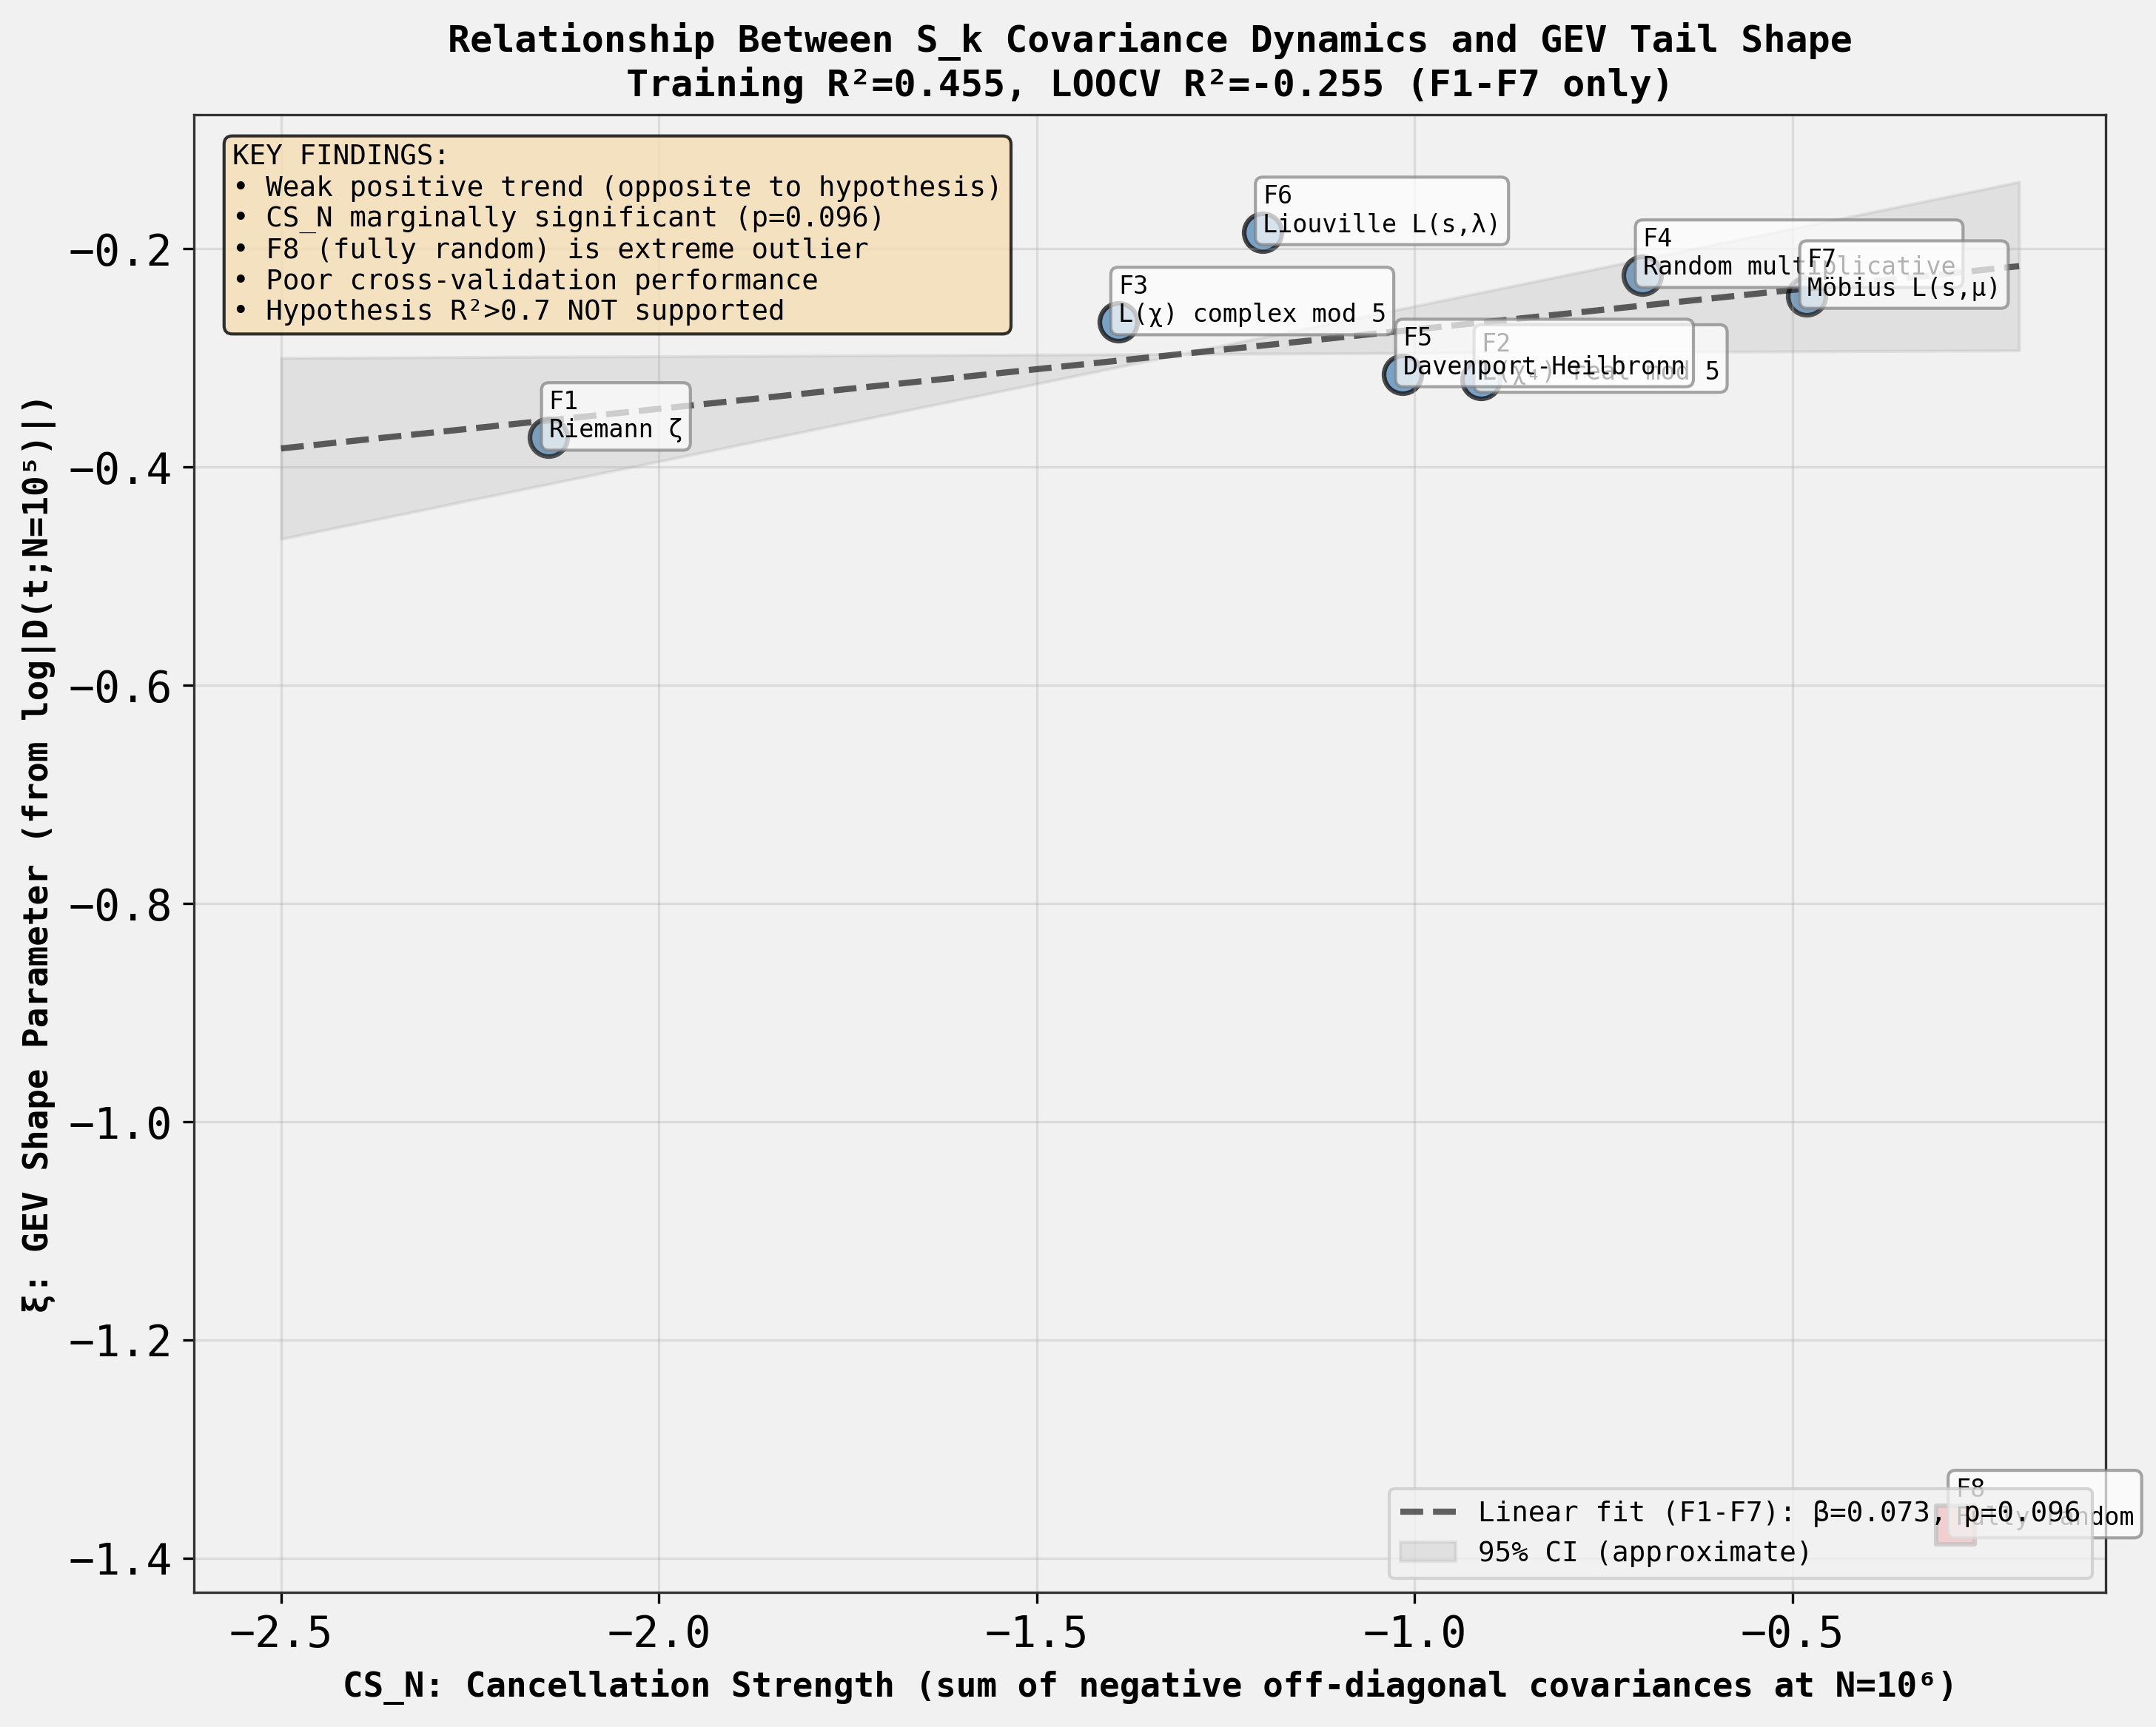

Final figure saved: final_regression_result.png


In [31]:

# Create a final comprehensive figure showing the key result
fig, ax = plt.subplots(figsize=(10, 8))

# Plot all functions
mask_f8 = merged_data_adj['Function_ID'] == 'F8'
colors = ['steelblue' if fid != 'F8' else 'red' 
 for fid in merged_data_adj['Function_ID']]
markers = ['o' if fid != 'F8' else 's' 
 for fid in merged_data_adj['Function_ID']]

for i, row in merged_data_adj.iterrows():
 ax.scatter(row['CS_N'], row['xi_shape'], 
 s=150, alpha=0.7, 
 color=colors[i], 
 marker=markers[i],
 edgecolors='black', linewidth=1.5)
 
 # Add labels with function names
 offset_x = 0.08 if row['Function_ID'] != 'F8' else 0.08
 offset_y = 0.015 if row['Function_ID'] != 'F1' else -0.025
 ax.annotate(f"{row['Function_ID']}\n{row['Function_Name']}", 
 (row['CS_N'], row['xi_shape']), 
 xytext=(offset_x, offset_y), 
 textcoords='offset points', 
 fontsize=8,
 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
 edgecolor='gray', alpha=0.7))

# Add regression line (without F8)
cs_range = np.linspace(-2.5, -0.2, 100)
xi_pred = results_cs_no_f8.params[0] + results_cs_no_f8.params[1] * cs_range
ax.plot(cs_range, xi_pred, 'k--', linewidth=2, alpha=0.6, 
 label=f'Linear fit (F1-F7): β={results_cs_no_f8.params[1]:.3f}, p={results_cs_no_f8.pvalues[1]:.3f}')

# Add shaded confidence region (approximate)
se_pred = results_cs_no_f8.bse[1]
xi_upper = (results_cs_no_f8.params[0] + 1.96*results_cs_no_f8.bse[0]) + \
 (results_cs_no_f8.params[1] + 1.96*se_pred) * cs_range
xi_lower = (results_cs_no_f8.params[0] - 1.96*results_cs_no_f8.bse[0]) + \
 (results_cs_no_f8.params[1] - 1.96*se_pred) * cs_range
ax.fill_between(cs_range, xi_lower, xi_upper, alpha=0.15, color='gray', 
 label='95% CI (approximate)')

ax.set_xlabel('CS_N: Cancellation Strength (sum of negative off-diagonal covariances at N=10⁶)', 
 fontsize=11, fontweight='bold')
ax.set_ylabel('ξ: GEV Shape Parameter (from log|D(t;N=10⁵)|)', 
 fontsize=11, fontweight='bold')
ax.set_title('Relationship Between S_k Covariance Dynamics and GEV Tail Shape\n' + 
 f'Training R²=0.455, LOOCV R²=-0.255 (F1-F7 only)', 
 fontsize=12, fontweight='bold')

# Add text box with key findings
textstr = '\n'.join([
 'KEY FINDINGS:',
 '• Weak positive trend (opposite to hypothesis)',
 '• CS_N marginally significant (p=0.096)',
 '• F8 (fully random) is extreme outlier',
 '• Poor cross-validation performance',
 '• Hypothesis R²>0.7 NOT supported'
])
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
 verticalalignment='top', bbox=props)

ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('final_regression_result.png', dpi=300, bbox_inches='tight')
plt.show()

print("Final figure saved: final_regression_result.png")
